Flood value counts immediately after loading:
flood
0    99
1    16
Name: count, dtype: int64
First Five Records
   Temp  Humidity  Cloud Cover  ANNUAL  Jan-Feb  Mar-May  Jun-Sep  Oct-Dec  \
0    29        70           30  3248.6     73.4    386.2   2122.8    666.1   
1    28        75           40  3326.6      9.3    275.7   2403.4    638.2   
2    28        75           42  3271.2     21.7    336.3   2343.0    570.1   
3    29        71           44  3129.7     26.7    339.4   2398.2    365.3   
4    31        74           40  2741.6     23.4    378.5   1881.5    458.1   

      avgjune    sub  flood  
0  274.866667  649.9      0  
1  130.300000  256.4      1  
2  186.200000  308.9      0  
3  366.066667  862.5      0  
4  283.400000  586.9      0  

Dataset Shape
(115, 11)

Column Names
Index(['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May',
       'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood'],
      dtype='object')

Dataset Information
<class 'pandas.core.frame

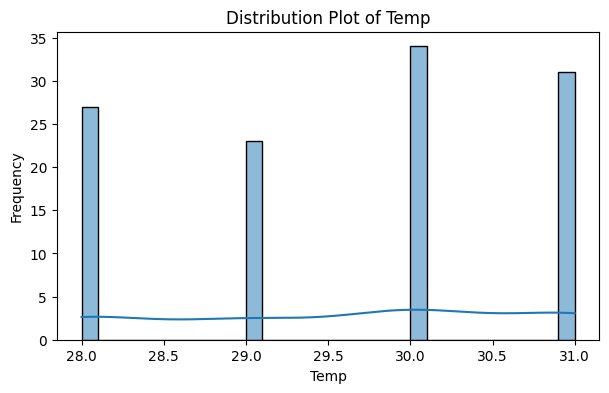

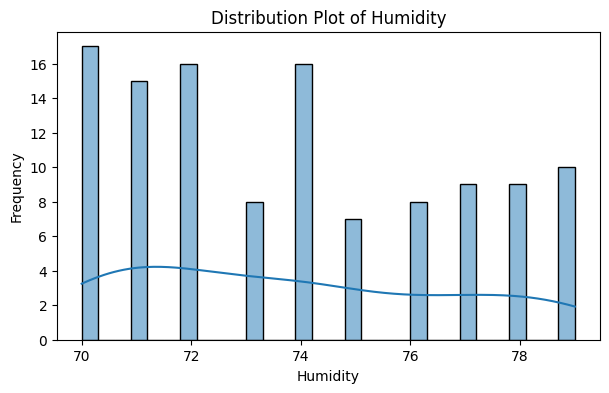

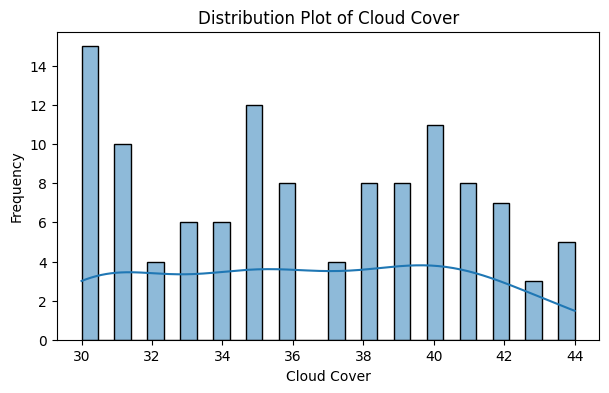

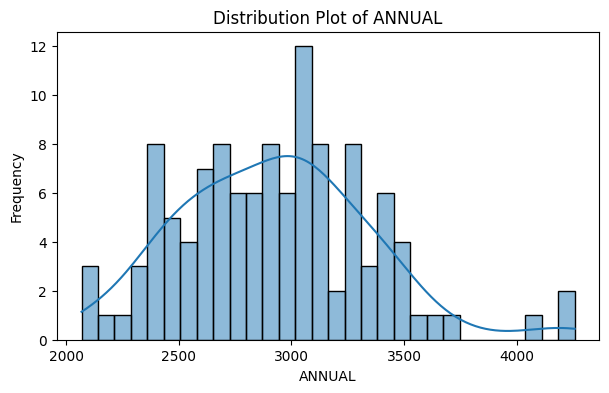

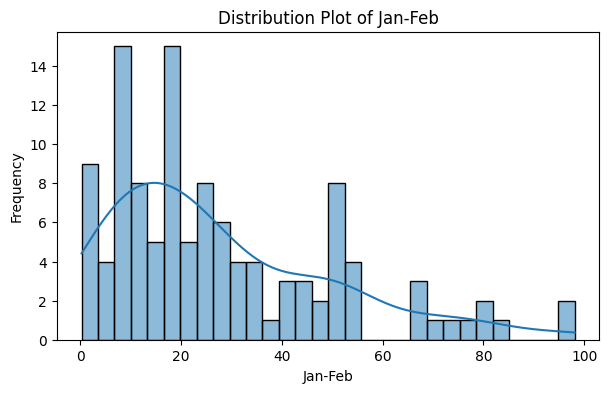

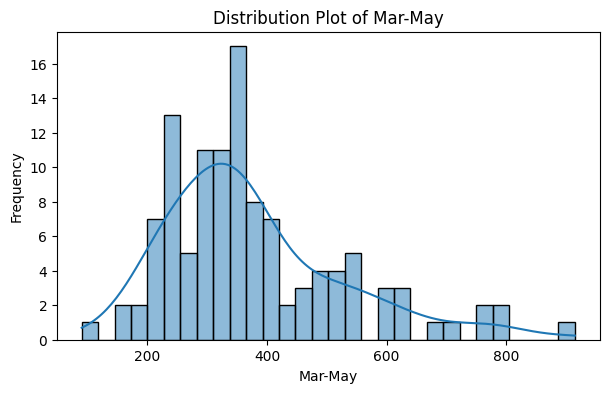

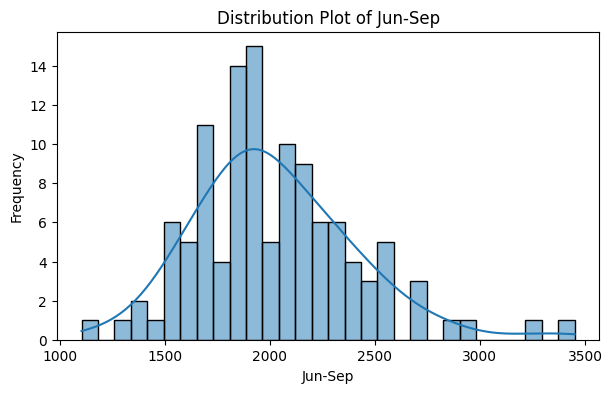

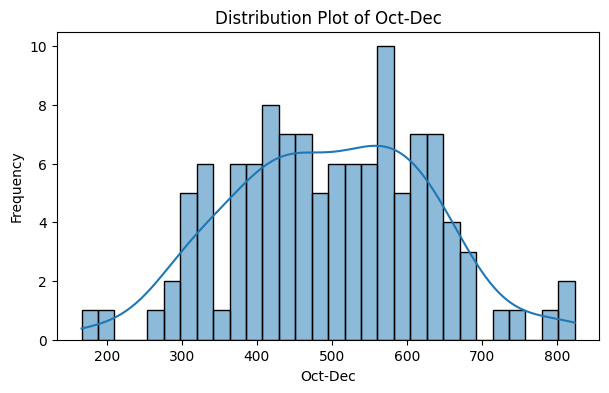

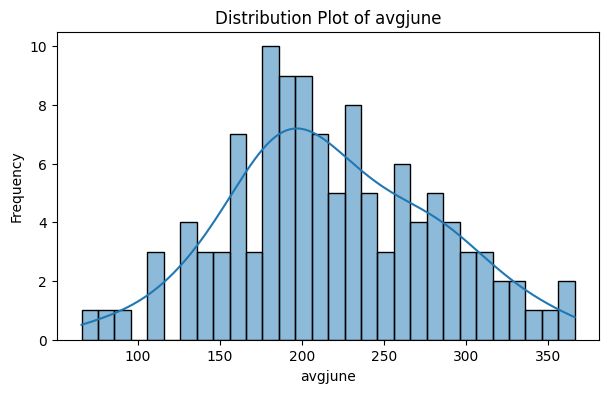

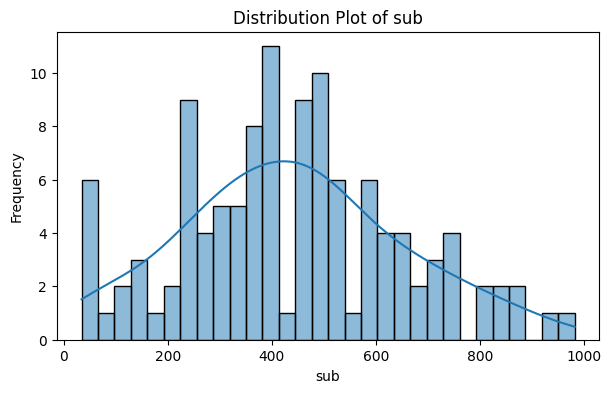

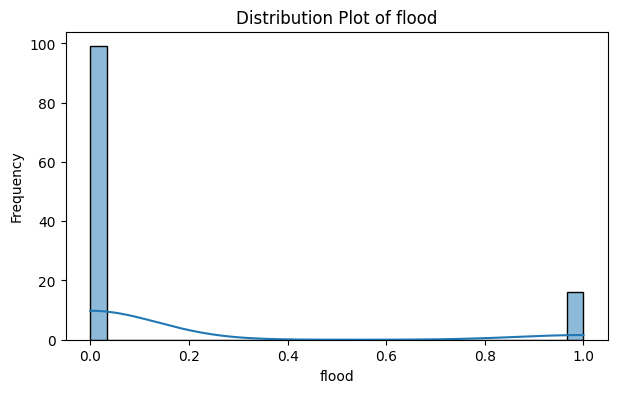

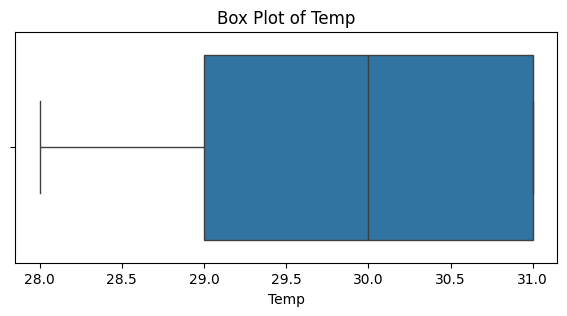

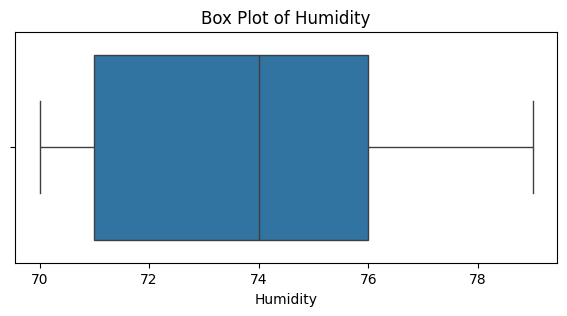

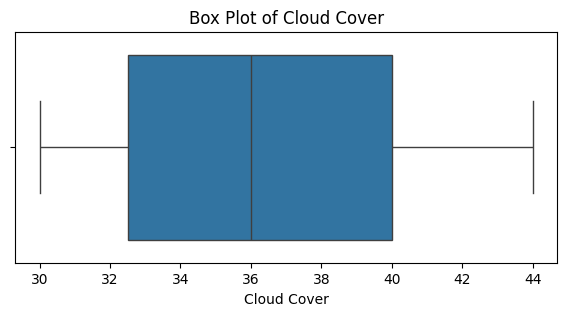

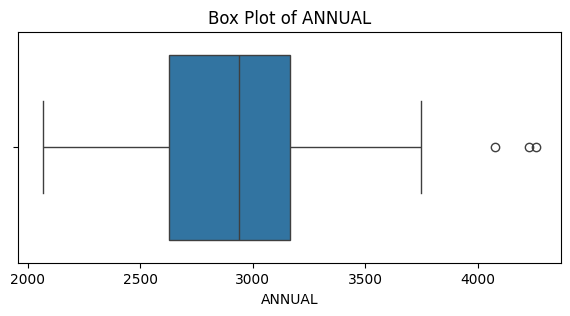

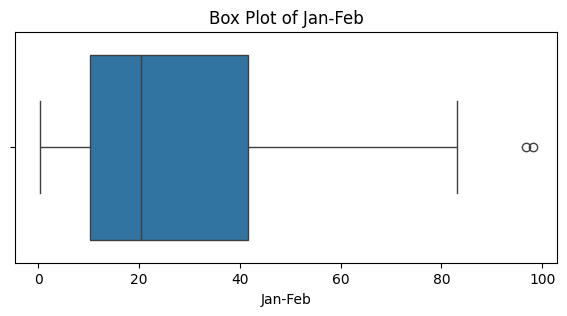

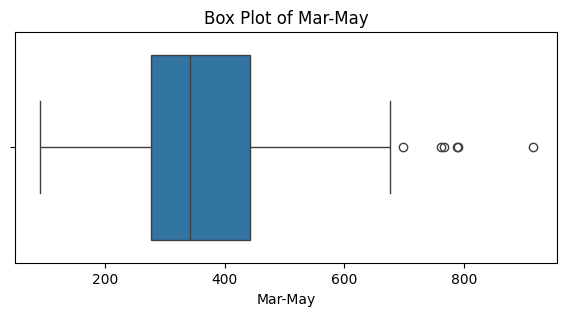

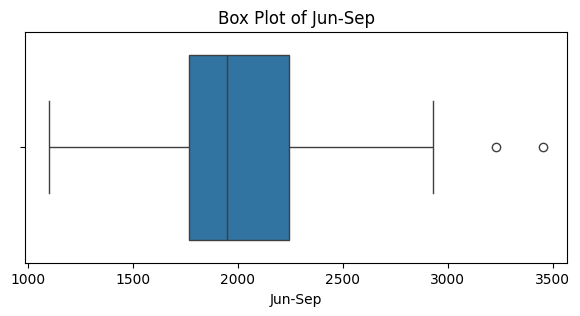

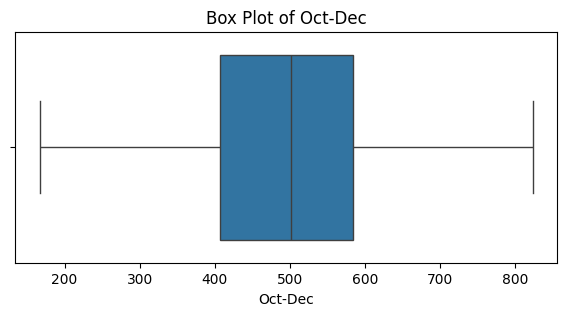

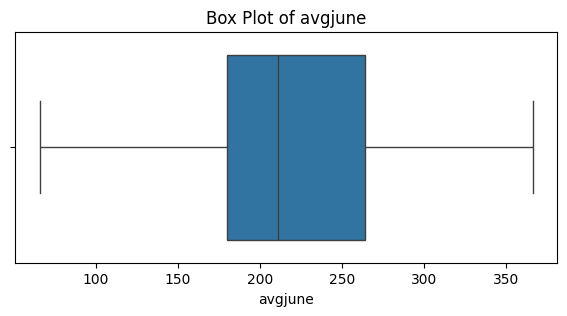

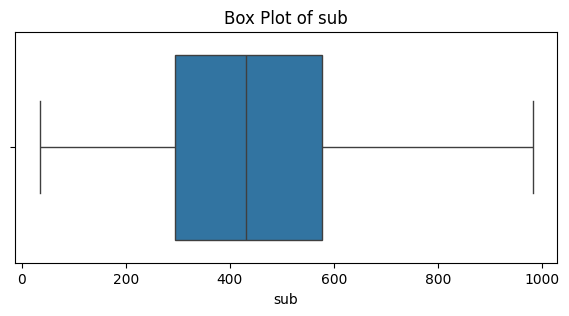

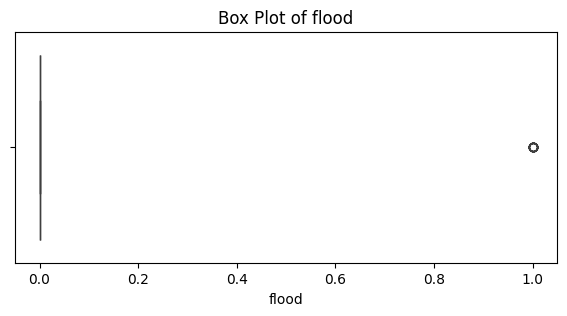


Correlation Matrix
                 Temp  Humidity  Cloud Cover    ANNUAL   Jan-Feb   Mar-May  \
Temp         1.000000 -0.012727    -0.046568 -0.063014 -0.080076  0.099519   
Humidity    -0.012727  1.000000     0.085824 -0.054767 -0.185965 -0.101232   
Cloud Cover -0.046568  0.085824     1.000000  0.051166  0.004376  0.096645   
ANNUAL      -0.063014 -0.054767     0.051166  1.000000  0.033639  0.387790   
Jan-Feb     -0.080076 -0.185965     0.004376  0.033639  1.000000  0.066479   
Mar-May      0.099519 -0.101232     0.096645  0.387790  0.066479  1.000000   
Jun-Sep     -0.081965 -0.029583     0.010833  0.861190  0.001178 -0.029007   
Oct-Dec     -0.063034  0.059739     0.020966  0.232069 -0.143670  0.171805   
avgjune     -0.019751  0.017656    -0.089843  0.474644  0.164691  0.019183   
sub         -0.088331  0.029981    -0.106455  0.220009  0.201266 -0.475750   
flood       -0.080946  0.020250     0.089801  0.626874 -0.084446 -0.017598   

              Jun-Sep   Oct-Dec   avgjune  

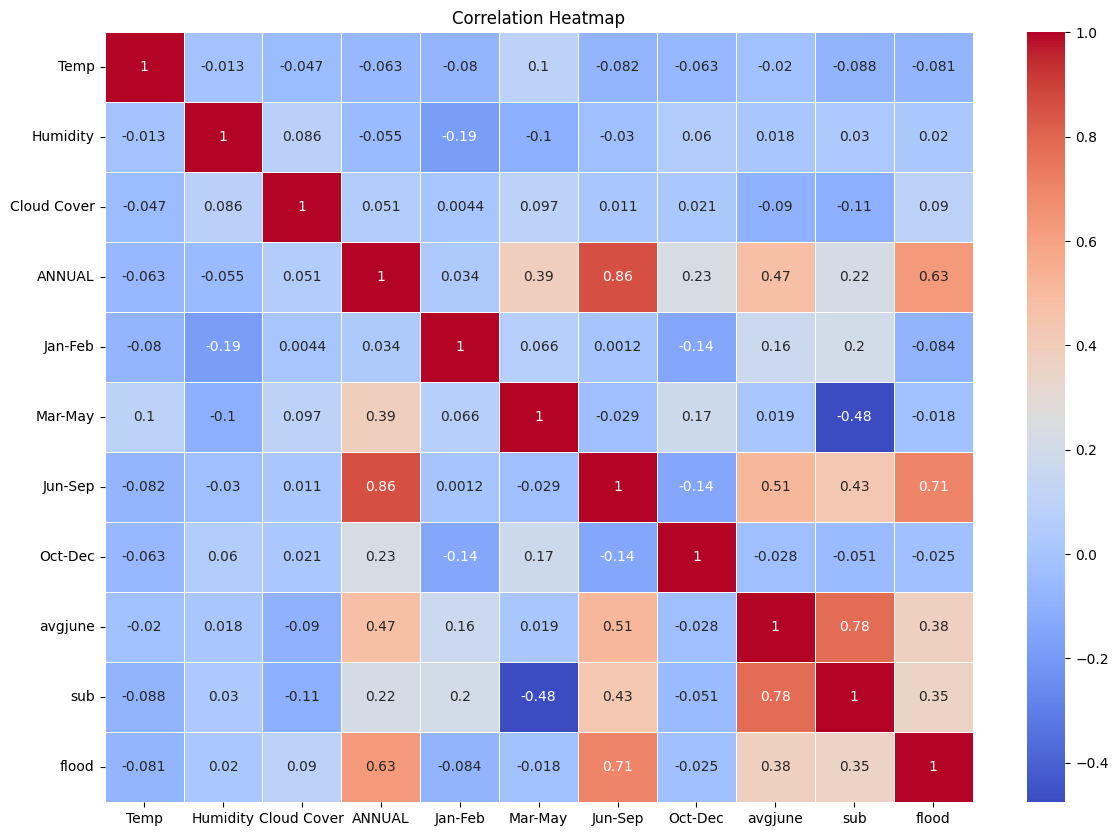

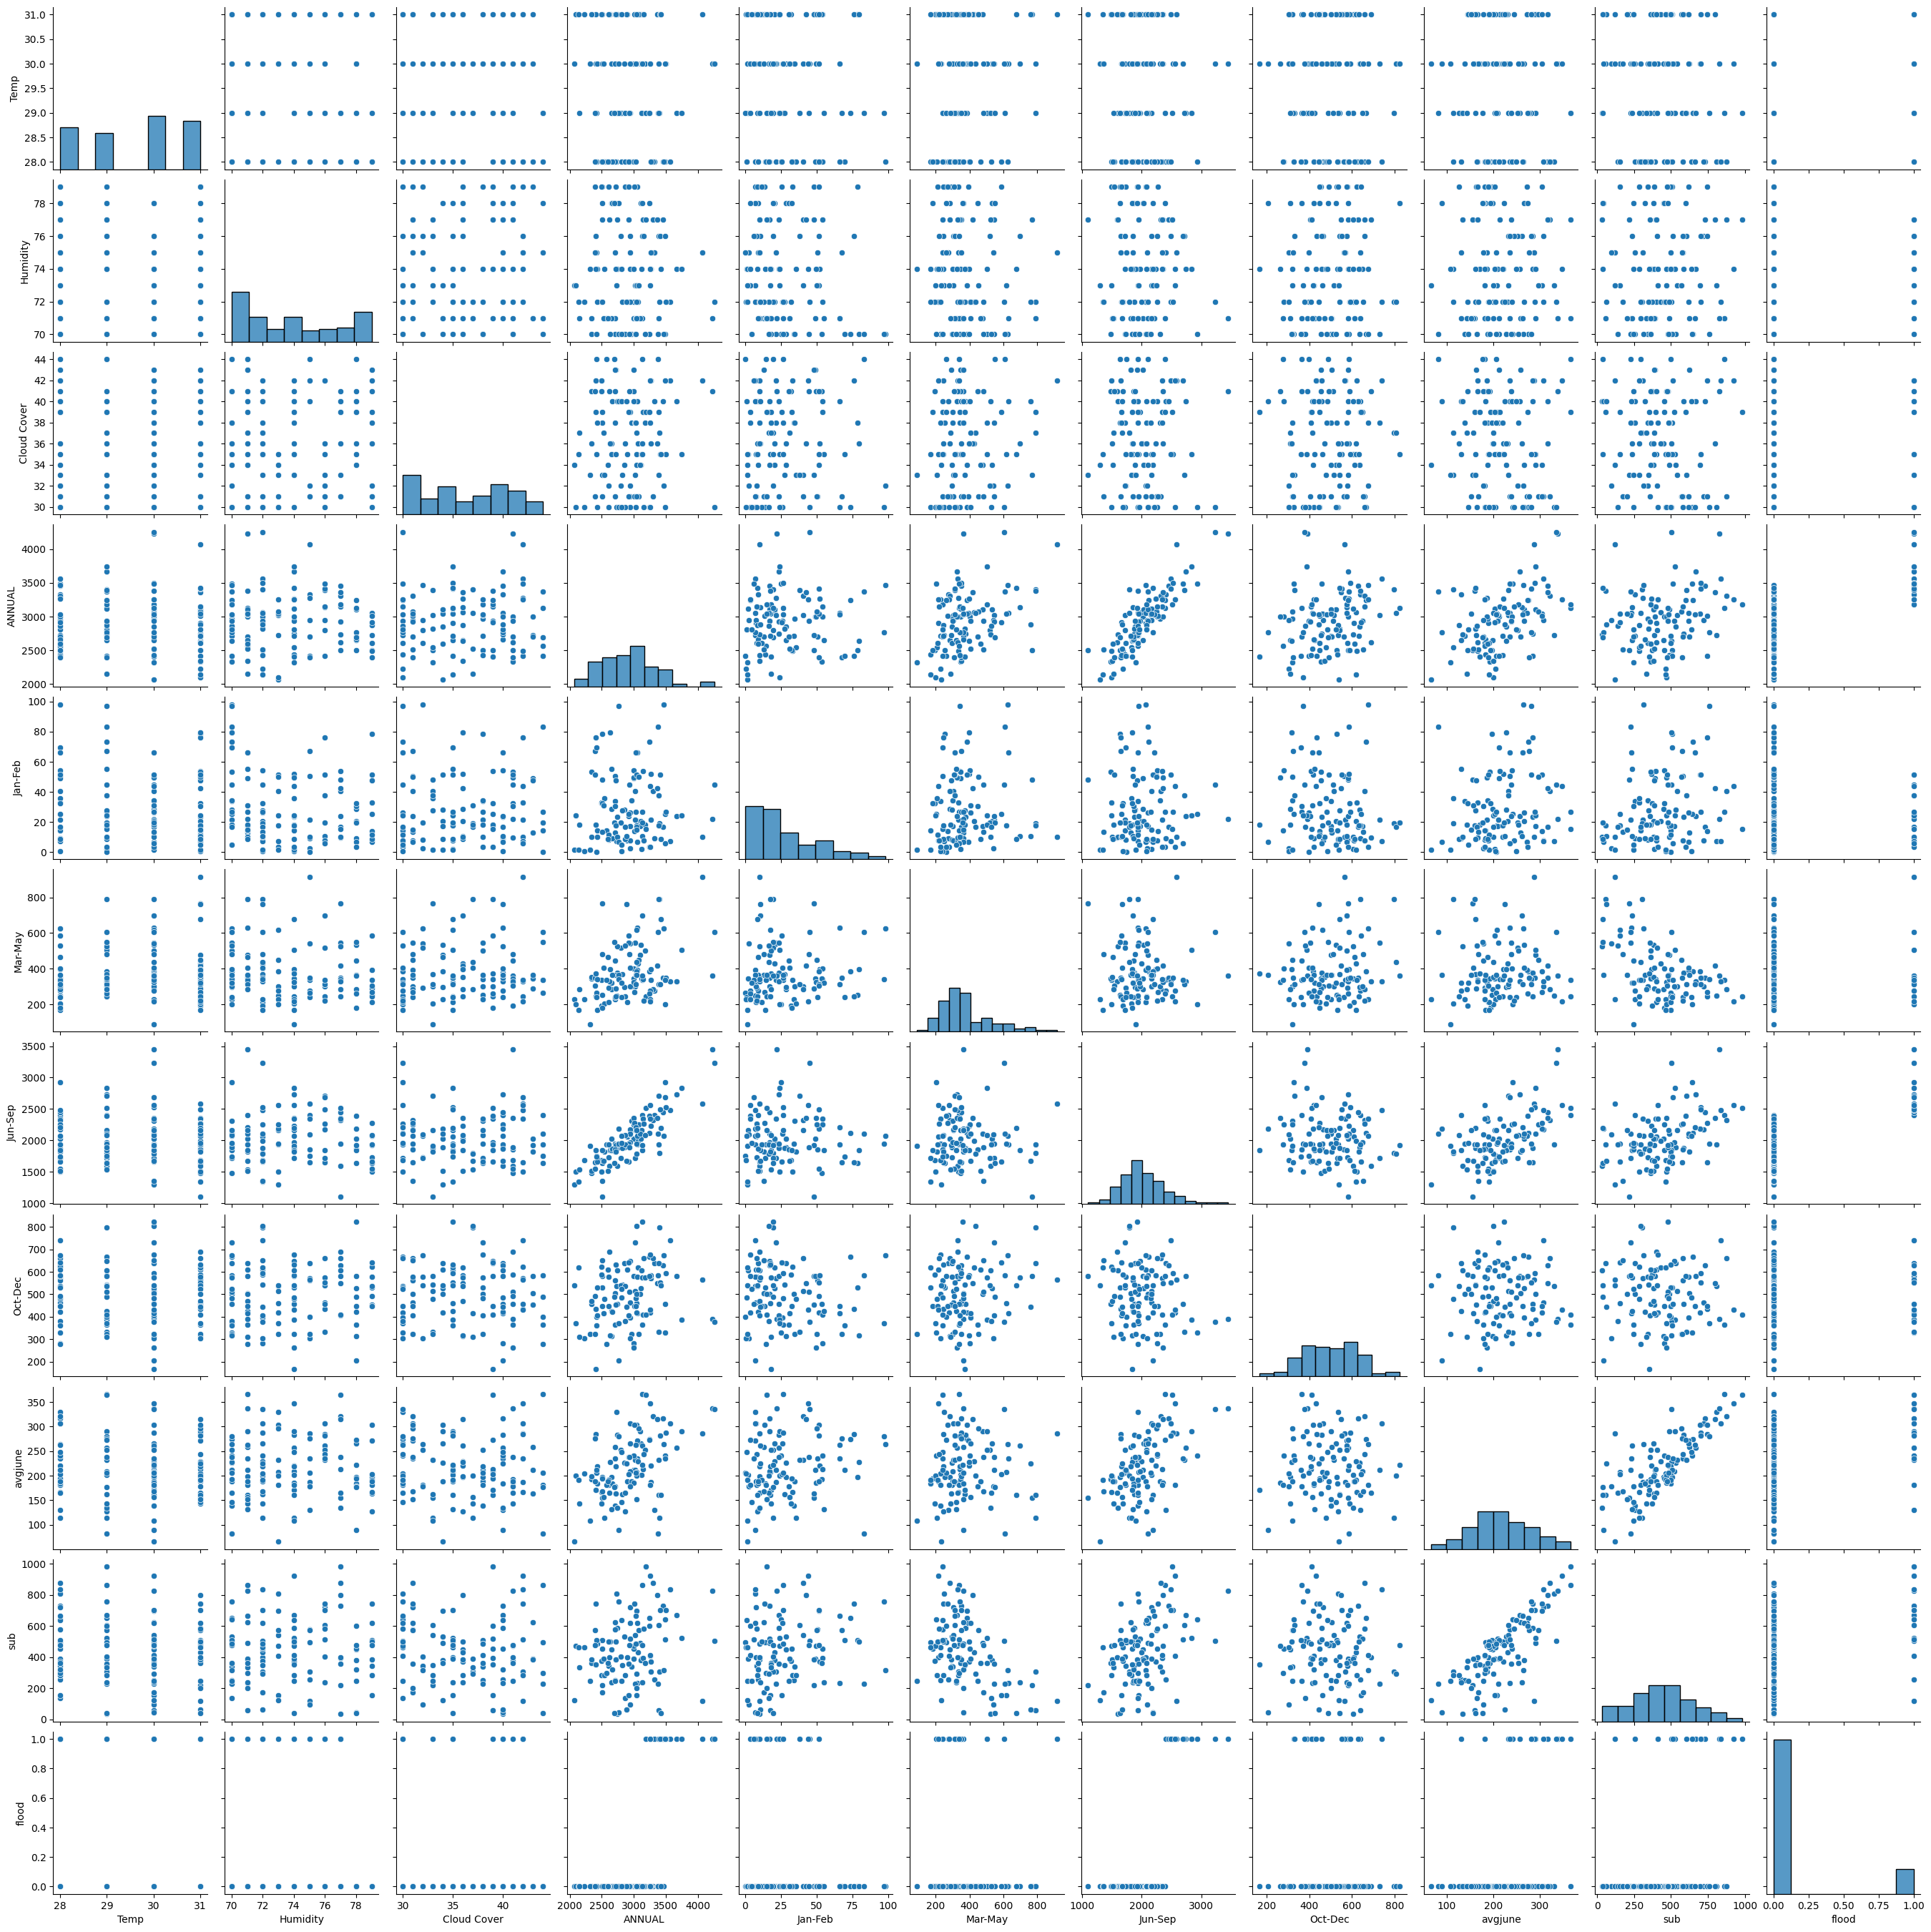

flood          1.000000
Jun-Sep        0.705202
ANNUAL         0.626874
avgjune        0.379778
sub            0.349828
Cloud Cover    0.089801
Humidity       0.020250
Mar-May       -0.017598
Oct-Dec       -0.024852
Temp          -0.080946
Jan-Feb       -0.084446
Name: flood, dtype: float64


In [1]:
# ================================
# Flood Prediction System
# Importing Libraries
# ================================

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

%matplotlib inline

# =====================================
# Load Dataset
# =====================================

# For Excel Dataset
df = pd.read_excel("flood dataset.xlsx")

print("Flood value counts immediately after loading:")
print(df["flood"].value_counts())



# =====================================
# Explore Dataset
# =====================================

print("First Five Records")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

print("\nDuplicate Records")
print(df.duplicated().sum())

print("\nData Types")
print(df.dtypes)

# =====================================
# Univariate Analysis
# =====================================

numerical_columns = df.select_dtypes(include=np.number).columns

print("\nNumerical Columns")
print(numerical_columns)

# Distribution Plots
for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.histplot(df[column],
                 kde=True,
                 bins=30)

    plt.title(f"Distribution Plot of {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.show()

# =====================================
# Box Plots
# =====================================

for column in numerical_columns:

    plt.figure(figsize=(7,3))

    sns.boxplot(x=df[column])

    plt.title(f"Box Plot of {column}")

    plt.show()

# =====================================
# Count Plots (Categorical Columns)
# =====================================

categorical_columns = df.select_dtypes(include="object").columns

if len(categorical_columns) > 0:

    for column in categorical_columns:

        plt.figure(figsize=(8,5))

        sns.countplot(data=df,
                      x=column)

        plt.xticks(rotation=45)

        plt.title(f"Count Plot of {column}")

        plt.show()

# =====================================
# Multivariate Analysis
# =====================================

correlation = df.corr(numeric_only=True)

print("\nCorrelation Matrix")

print(correlation)

plt.figure(figsize=(14,10))

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

# =====================================
# Pair Plot
# =====================================

sns.pairplot(df)

plt.show()

# =====================================
# Correlation with Target Variable
# =====================================


print(correlation["flood"].sort_values(ascending=False))

# =====================================
# End of Exploratory Data Analysis
# =====================================

In [2]:
# ==========================================================
# DATA PREPROCESSING
# ==========================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------
# Reload dataset (important if you rerun notebook cells)
# ----------------------------------------------------------

df = pd.read_excel("flood dataset.xlsx")

print("=" * 60)
print("Original Target Distribution")
print("=" * 60)
print(df["flood"].value_counts())

# ==========================================================
# 1. HANDLE MISSING VALUES
# ==========================================================

print("\nMissing Values")
print(df.isnull().sum())

if df.isnull().sum().sum() != 0:

    for column in df.columns:

        if df[column].dtype == "object":
            df[column].fillna(df[column].mode()[0], inplace=True)

        else:
            df[column].fillna(df[column].median(), inplace=True)

print("\nAfter Missing Value Handling")
print(df["flood"].value_counts())

# ==========================================================
# 2. HANDLE OUTLIERS USING IQR CAPPING
# ==========================================================


feature_columns = df.drop("flood", axis=1).columns

for column in feature_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = np.where(df[column] < lower, lower, df[column])
    df[column] = np.where(df[column] > upper, upper, df[column])

print("\nAfter Outlier Handling")
print(df["flood"].value_counts())

# ==========================================================
# 3. HANDLE CATEGORICAL VARIABLES
# ==========================================================

categorical_columns = df.select_dtypes(include="object").columns

if len(categorical_columns) > 0:

    from sklearn.preprocessing import LabelEncoder

    encoder = LabelEncoder()

    for column in categorical_columns:
        df[column] = encoder.fit_transform(df[column])

print("\nAfter Encoding")
print(df["flood"].value_counts())

# ==========================================================
# 4. SPLIT FEATURES AND TARGET
# ==========================================================

X = df.drop("flood", axis=1)
y = df["flood"]

print("\nFinal Target Distribution")
print(y.value_counts())

# ==========================================================
# 5. TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts())

# ==========================================================
# 6. FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("\nData Preprocessing Completed Successfully.")

Original Target Distribution
flood
0    99
1    16
Name: count, dtype: int64

Missing Values
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

After Missing Value Handling
flood
0    99
1    16
Name: count, dtype: int64

After Outlier Handling
flood
0    99
1    16
Name: count, dtype: int64

After Encoding
flood
0    99
1    16
Name: count, dtype: int64

Final Target Distribution
flood
0    99
1    16
Name: count, dtype: int64

Training Target Distribution
flood
0    79
1    13
Name: count, dtype: int64

Testing Target Distribution
flood
0    20
1     3
Name: count, dtype: int64

Data Preprocessing Completed Successfully.


In [3]:
# ==========================================================
# MODEL BUILDING
# ==========================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import joblib

# ==========================================================
# DECISION TREE
# ==========================================================

def decisionTree(X_train, X_test, y_train, y_test):

    print("="*70)
    print("DECISION TREE")
    print("="*70)

    model = DecisionTreeClassifier(random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy :", accuracy)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return model, y_pred, accuracy


# ==========================================================
# RANDOM FOREST
# ==========================================================

def randomForest(X_train, X_test, y_train, y_test):

    print("="*70)
    print("RANDOM FOREST")
    print("="*70)

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy :", accuracy)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return model, y_pred, accuracy


# ==========================================================
# KNN
# ==========================================================

def KNN(X_train, X_test, y_train, y_test):

    print("="*70)
    print("K NEAREST NEIGHBOR")
    print("="*70)

    model = KNeighborsClassifier(
        n_neighbors=5
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy :", accuracy)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return model, y_pred, accuracy


# ==========================================================
# XGBOOST
# ==========================================================

def XGBoost(X_train, X_test, y_train, y_test):

    print("="*70)
    print("XGBOOST")
    print("="*70)

    model = XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print("Accuracy :", accuracy)

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    return model, y_pred, accuracy


# ==========================================================
# TRAIN ALL MODELS
# ==========================================================

dt_model, dt_pred, dt_acc = decisionTree(
    X_train,
    X_test,
    y_train,
    y_test
)

rf_model, rf_pred, rf_acc = randomForest(
    X_train,
    X_test,
    y_train,
    y_test
)

knn_model, knn_pred, knn_acc = KNN(
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_model, xgb_pred, xgb_acc = XGBoost(
    X_train,
    X_test,
    y_train,
    y_test
)


# ==========================================================
# MODEL COMPARISON
# ==========================================================

print("\n")
print("="*70)
print("MODEL COMPARISON")
print("="*70)

accuracy_scores = {
    "Decision Tree": dt_acc,
    "Random Forest": rf_acc,
    "KNN": knn_acc,
    "XGBoost": xgb_acc
}

for model, score in accuracy_scores.items():
    print(f"{model:20s} : {score:.4f}")

best_model_name = max(accuracy_scores, key=accuracy_scores.get)

print("\nBest Model :", best_model_name)


# ==========================================================
# SAVE BEST MODEL
# ==========================================================

if best_model_name == "Decision Tree":
    best_model = dt_model

elif best_model_name == "Random Forest":
    best_model = rf_model

elif best_model_name == "KNN":
    best_model = knn_model

else:
    best_model = xgb_model


joblib.dump(best_model, "floods.save")

joblib.dump(scaler, "transform.save")

print("\nModel Saved Successfully")
print("Saved File : floods.save")
print("Scaler Saved : transform.save")

DECISION TREE
Accuracy : 0.9565217391304348

Confusion Matrix
[[20  0]
 [ 1  2]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23

RANDOM FOREST
Accuracy : 0.9565217391304348

Confusion Matrix
[[20  0]
 [ 1  2]]

Classification Report
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        20
           1       1.00      0.67      0.80         3

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.89        23
weighted avg       0.96      0.96      0.95        23

K NEAREST NEIGHBOR
Accuracy : 0.8695652173913043

Confusion Matrix
[[19  1]
 [ 2  1]]

Classification Report
              precision    re